In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
data = pd.read_csv(r"C:\ML Project 7 Car Price Prediction using Linear & Lasso Regression\car data.csv")

In [8]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [9]:
data = data.drop('Car_Name', axis=1)

In [10]:
data.head(3)

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0


In [11]:
data.isnull().sum()

Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

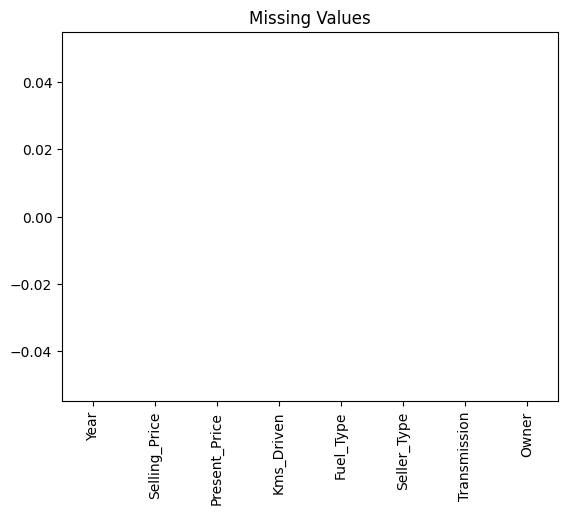

In [12]:
data.isnull().sum().plot(kind='bar')
plt.title("Missing Values")
plt.show()

In [13]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 non-null    int64  
 4   Fuel_Type      301 non-null    str    
 5   Seller_Type    301 non-null    str    
 6   Transmission   301 non-null    str    
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 24.8 KB


In [14]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


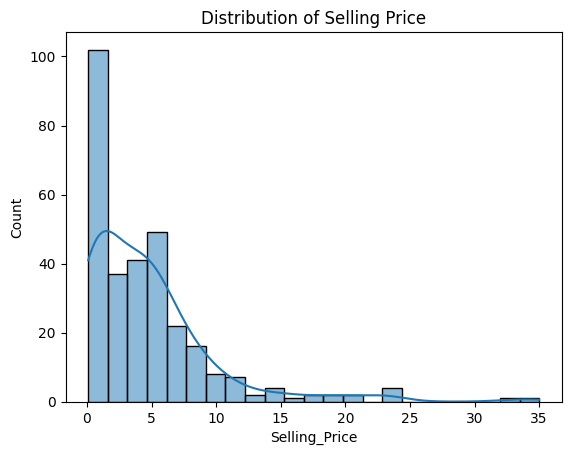

In [15]:
sns.histplot(data['Selling_Price'], kde=True)
plt.title("Distribution of Selling Price")
plt.show()

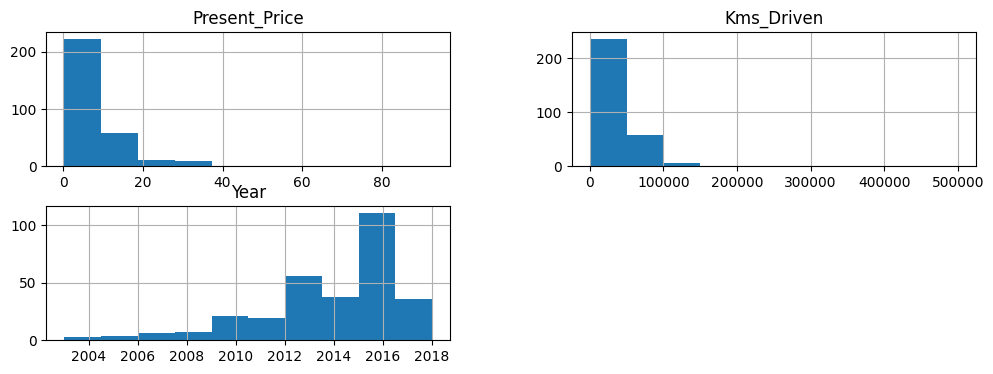

In [16]:
data[['Present_Price','Kms_Driven','Year']].hist(figsize=(12,4))
plt.show()

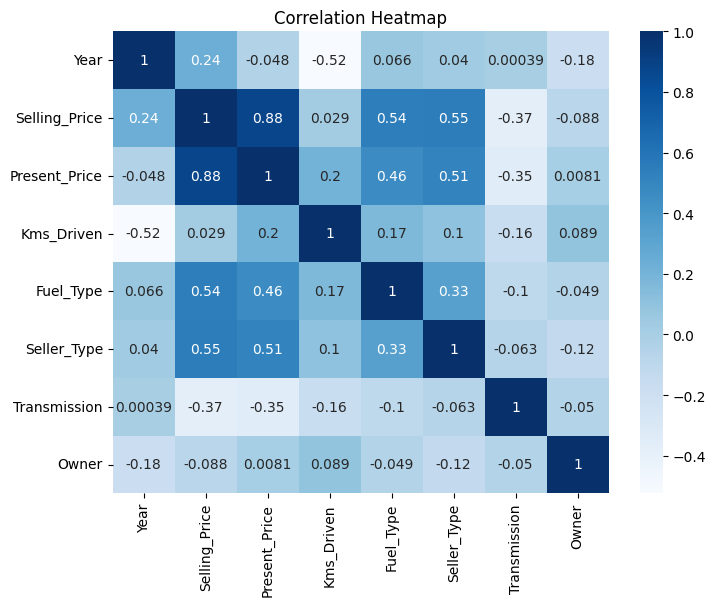

In [41]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(),annot=True,cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
data.shape

(301, 8)

In [20]:
data['Fuel_Type'].value_counts()

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

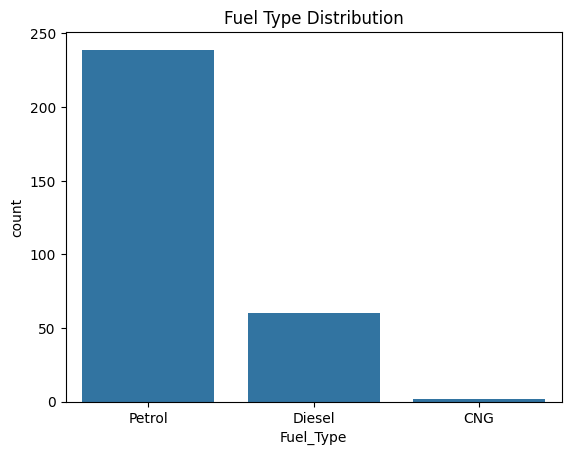

In [21]:
sns.countplot(x='Fuel_Type',data=data)
plt.title("Fuel Type Distribution")
plt.show()

In [22]:
data['Seller_Type'].value_counts()

Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

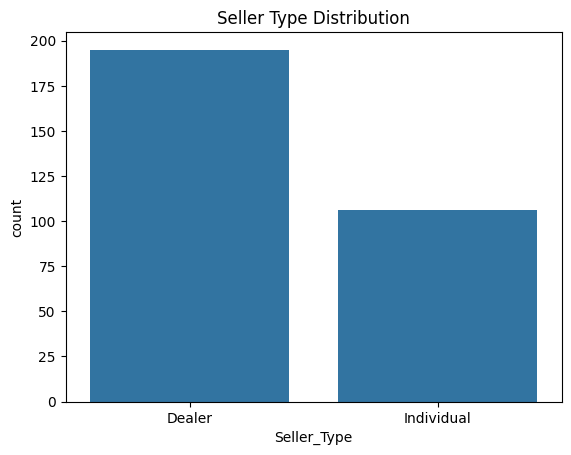

In [23]:
sns.countplot(x='Seller_Type',data=data)
plt.title("Seller Type Distribution")
plt.show()

In [24]:
data['Transmission'].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

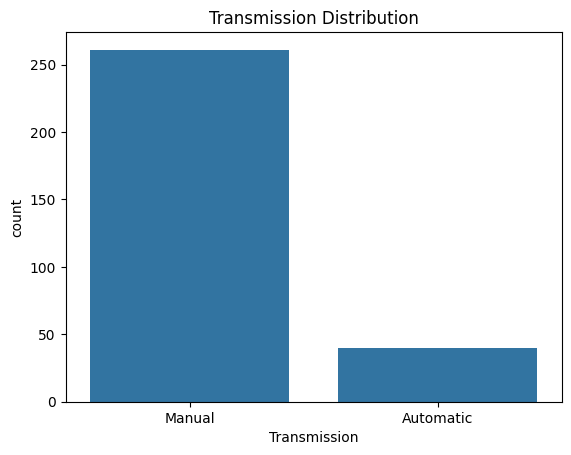

In [25]:
sns.countplot(x='Transmission',data=data)
plt.title("Transmission Distribution")
plt.show()

In [26]:
data['Owner'].value_counts()

Owner
0    290
1     10
3      1
Name: count, dtype: int64

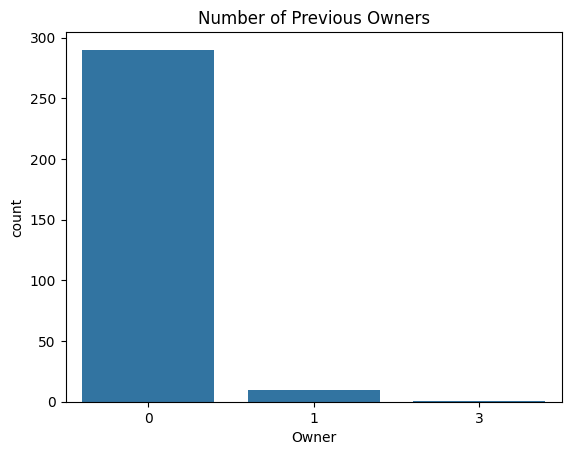

In [27]:
sns.countplot(x='Owner',data=data)
plt.title("Number of Previous Owners")
plt.show()

In [28]:
data = data.replace({
    'Fuel_Type':{'CNG':0, 'Petrol':1, 'Diesel':2},
    'Seller_Type':{'Dealer':1, 'Individual':0},
    'Transmission':{'Manual':1, 'Automatic':0}
})

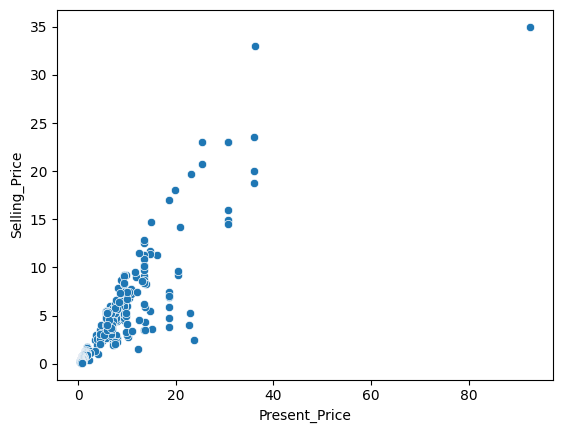

In [29]:
sns.scatterplot(x='Present_Price',
                y='Selling_Price',
                data=data)
plt.show()

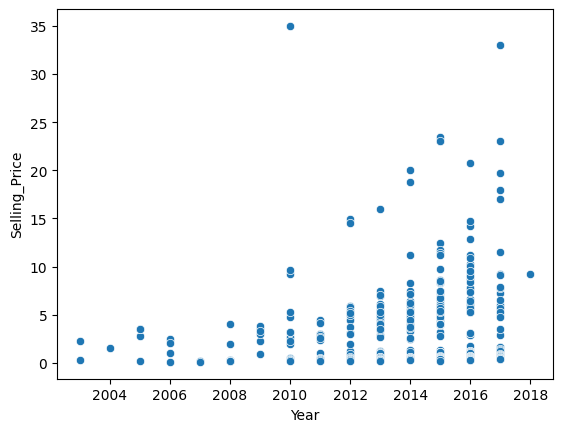

In [30]:
sns.scatterplot(x='Year',
                y='Selling_Price',
                data=data)
plt.show()

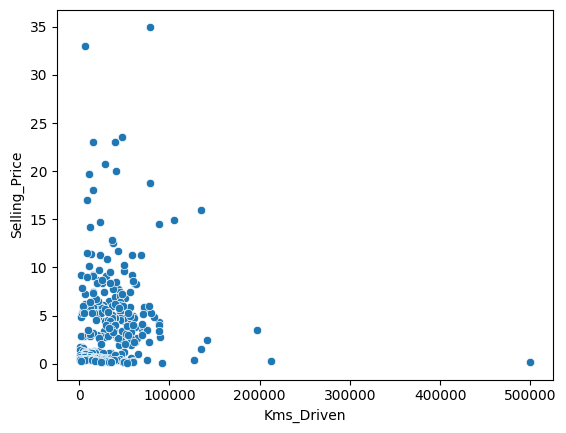

In [31]:
sns.scatterplot(x='Kms_Driven',
                y='Selling_Price',
                data=data)
plt.show()

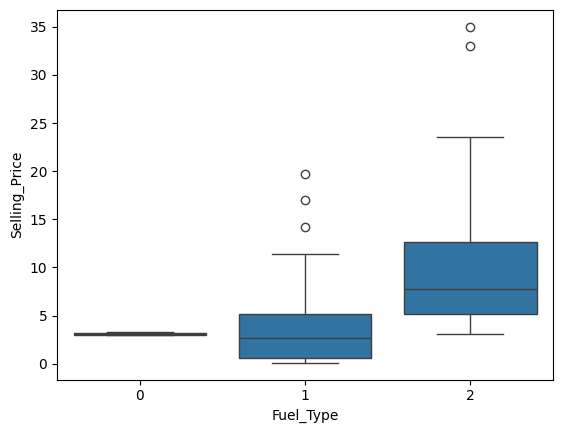

In [32]:
sns.boxplot(x='Fuel_Type',
            y='Selling_Price',
            data=data)
plt.show()

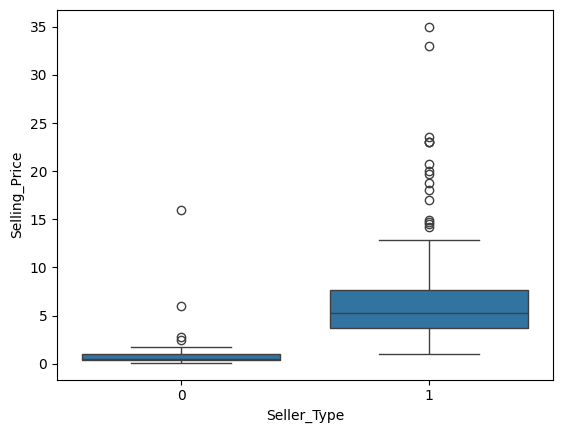

In [33]:
sns.boxplot(x='Seller_Type',
            y='Selling_Price',
            data=data)
plt.show()

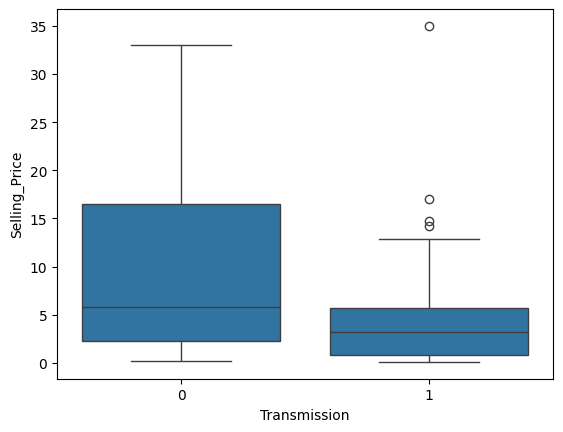

In [34]:
sns.boxplot(x='Transmission',
            y='Selling_Price',
            data=data)
plt.show()

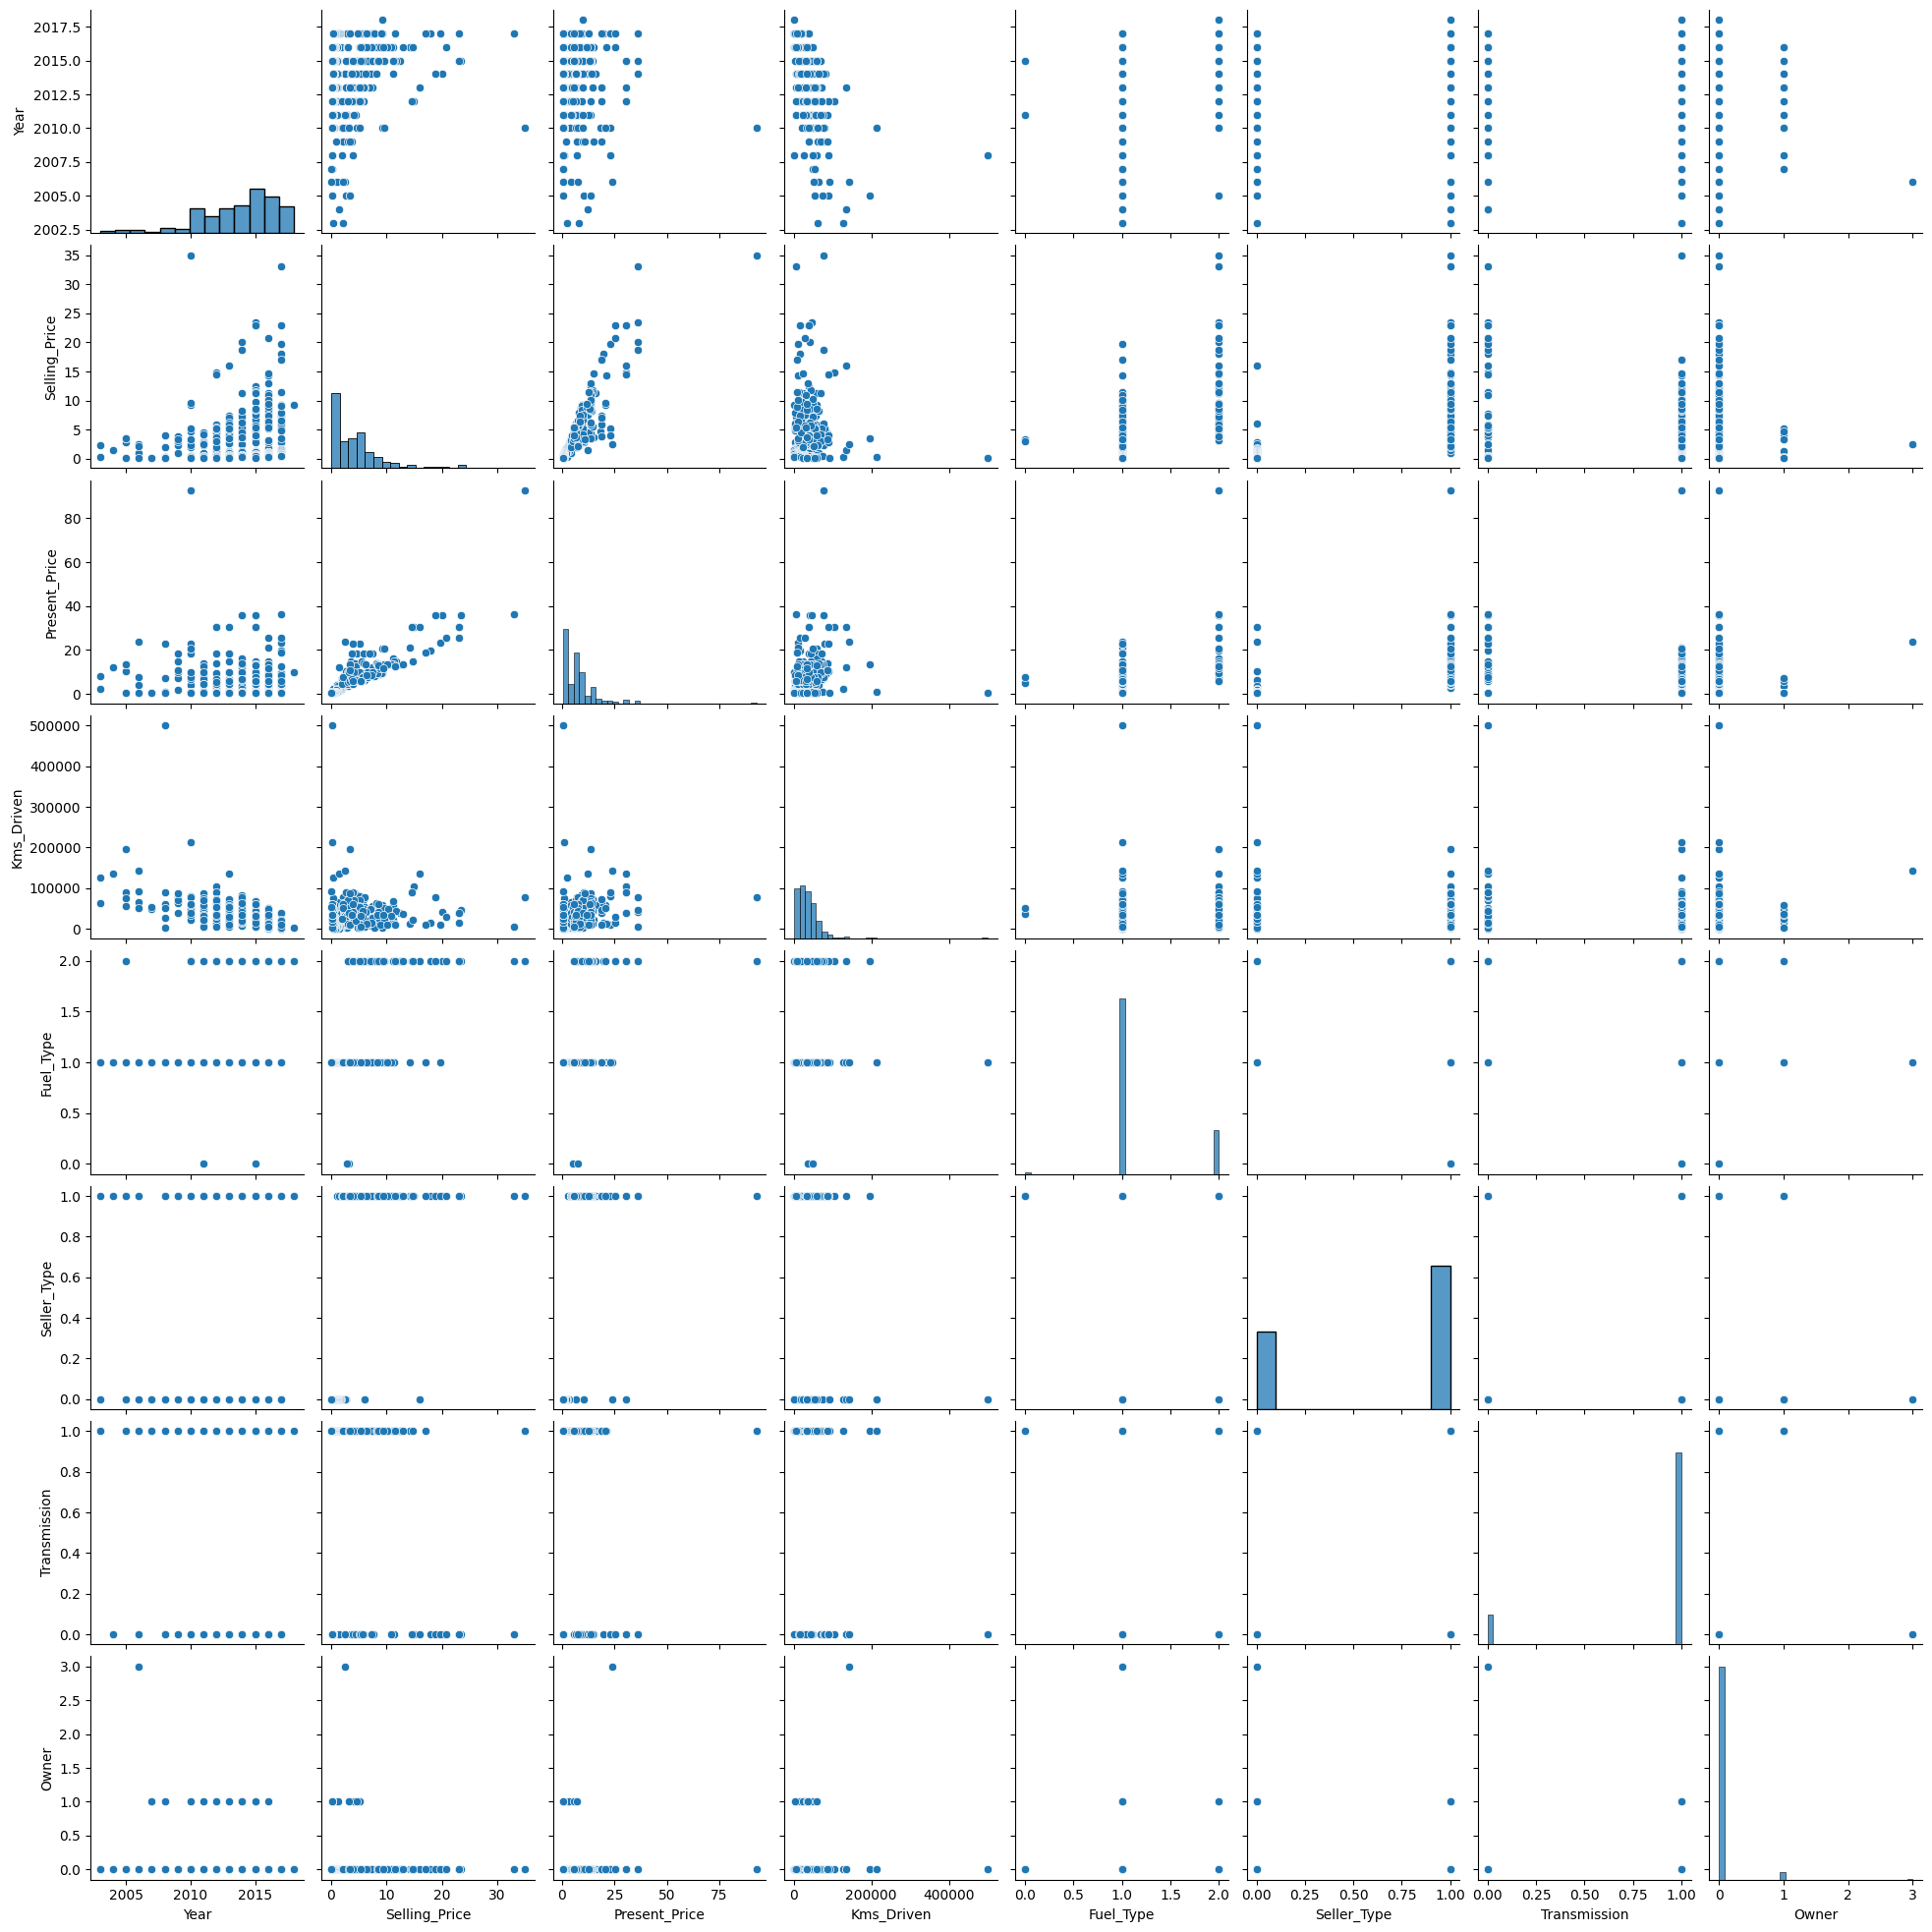

In [35]:
sns.pairplot(data)
plt.show()

In [36]:
data.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,1,1,1,0
1,2013,4.75,9.54,43000,2,1,1,0
2,2017,7.25,9.85,6900,1,1,1,0
3,2011,2.85,4.15,5200,1,1,1,0
4,2014,4.60,6.87,42450,2,1,1,0


In [37]:
x = data.drop('Selling_Price', axis=1)

In [38]:
x

,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,5.59,27000,1,1,1,0
1,2013,9.54,43000,2,1,1,0
2,2017,9.85,6900,1,1,1,0
3,2011,4.15,5200,1,1,1,0
4,2014,6.87,42450,2,1,1,0
...,...,...,...,...,...,...,...
296,2016,11.60,33988,2,1,1,0
297,2015,5.90,60000,1,1,1,0
298,2009,11.00,87934,1,1,1,0
299,2017,12.50,9000,2,1,1,0


In [39]:
y = data['Selling_Price']

In [40]:
y

0       3.35
1       4.75
2       7.25
3       2.85
4       4.60
       ...  
296     9.50
297     4.00
298     3.35
299    11.50
300     5.30
Name: Selling_Price, Length: 301, dtype: float64

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [44]:
x.shape, x_train.shape, x_test.shape

((301, 7), (225, 7), (76, 7))

In [45]:
y_train.shape, y_test.shape

((225,), (76,))

# Using Linear Regression

In [46]:
from sklearn.linear_model import LinearRegression

In [47]:
model = LinearRegression(
    fit_intercept=True,
    copy_X=True,
    tol=1e-6,
    n_jobs=None,
    positive=False
)

In [48]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.37, 0.43,-0. ,..., 1.29,-1.55,-1.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Year','Present_Price','Kms_Driven',...,'Seller_Type','Transmission', 'Owner']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-738.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [49]:
from sklearn.metrics import accuracy_score

In [50]:
model.score(x_train, y_train)*100

88.26341967264459

In [51]:
model.score(x_test, y_test)*100

87.63429135446728

In [52]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model.predict(x_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))

MAE: 1.2329675174569374
RMSE: 1.8432016535642868
R²: 0.8763429135446729


In [64]:
new_data = pd.DataFrame([[
    2014,     
    5.59,    
    27000,         
    1,         
    1,         
    1,
    0
]], columns=x.columns)

prediction = model.predict(new_data)

print("Predicted Selling Price:", round(prediction[0], 2))

Predicted Selling Price: 4.0


In [65]:
import pickle

pickle.dump(model, open('car_price_prediction.sav', 'wb'))

# Using Lasso Regression

In [54]:
from sklearn.linear_model import Lasso

In [55]:
model_lasso = Lasso()

In [56]:
model_lasso.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [57]:
model_lasso.score(x_train, y_train)*100

83.93865364610689

In [58]:
model_lasso.score(x_test, y_test)*100

83.78718007612107

In [59]:
pred_lasso = model_lasso.predict(x_test)

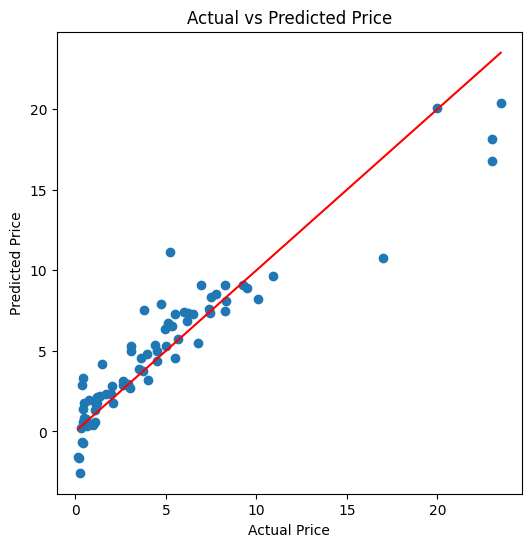

In [60]:
pred = model.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test,pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

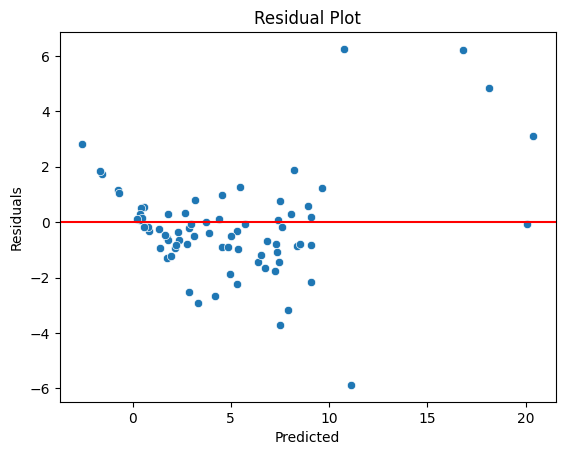

In [61]:
residuals = y_test - pred

sns.scatterplot(x=pred,
                y=residuals)
plt.axhline(0,color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred = model_lasso.predict(x_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R²:", r2_score(y_test, pred))

MAE: 1.4121383533497884
RMSE: 2.1105353273962106
R²: 0.8378718007612107


In [63]:
new_data = pd.DataFrame([[
    2019,     
    1.59,    
    13000,         
    0,         
    1,         
    0,
    0
]], columns=x.columns)

prediction = model_lasso.predict(new_data)

print("Predicted Selling Price:", round(prediction[0], 2))

Predicted Selling Price: 3.42
